# Earthkit Africa Flat Precipitation

Notebook Earthkit avec le meme style de presentation que les rendus precedents, mais applique a la precipitation sur une projection plate focalisee sur l'Afrique.

In [2]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthkit
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

In [38]:
precipitation = earthkit.data.from_source(
    'cds',
    'derived-era5-single-levels-daily-statistics',
    {
        'product_type': 'reanalysis',
        'variable': ['total_precipitation'],
        'year': '2026',
        'month': ['03'],
        'day': ['01'],
        'daily_statistic': 'daily_mean',
        'time_zone': 'utc+00:00',
        'frequency': '1_hourly',
    },
)

datetime_for_plot = '2026-03-01 (UTC)'

2026-04-10 10:42:52,255 INFO Request ID is db4d975b-0927-45bd-a0ce-95f3dcaab858
2026-04-10 10:42:52,345 INFO status has been updated to accepted
2026-04-10 10:43:00,895 INFO status has been updated to running
2026-04-10 10:43:06,083 INFO status has been updated to successful


In [39]:
precipitation_style = earthkit.plots.styles.Style(
    colors=[
        '#1b9e77', '#2fb47c', '#7ad151', '#bddf26',
        '#fde725', '#fdb366', '#f67e4b', '#e34a33',
        '#b30000', '#7a0177', '#542788', '#2d004b',
    ],
    levels=[0, 0.1, 0.25, 0.75, 1, 1.5, 2, 3, 6, 12, 18, 30, 40],
    extend='max',
    units='mm',
)

crs = ccrs.LambertAzimuthalEqualArea(central_longitude=20, central_latitude=5)

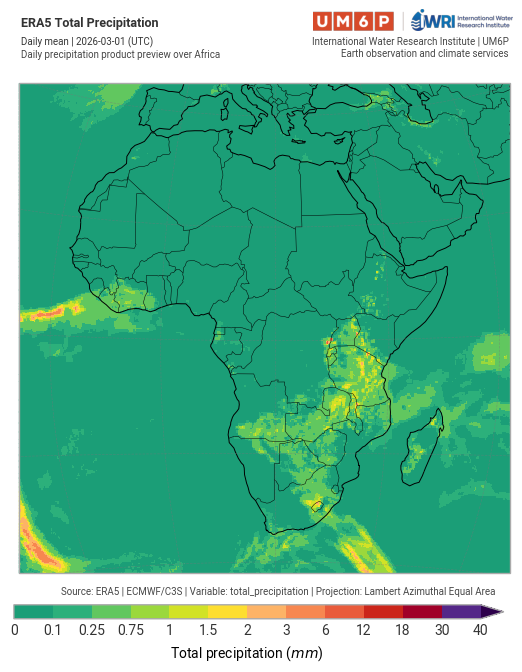

In [40]:
earthkit.plots.schema.figsize = (8, 8)

chart = earthkit.plots.Map(crs=crs)
chart.pcolormesh(precipitation, style=precipitation_style)
chart.legend(location='bottom', shrink=0.86)

fig = plt.gcf()
fig.patch.set_facecolor('white')

# Reserve clear bands for header, map and colorbar like a product layout.
map_ax = fig.axes[0]
cbar_ax = fig.axes[1] if len(fig.axes) > 1 else None
map_ax.set_position([0.10, 0.15, 0.75, 0.70])
if cbar_ax is not None:
    cbar_ax.set_position([0.12, 0.085, 0.70, 0.020])

ax = map_ax

ax.set_extent([-26, 62, -40, 42], crs=ccrs.PlateCarree())
ax.coastlines(resolution='110m', color='black', linewidth=0.7)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.35)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.5,
    color='#777777',
    alpha=0.45,
    linestyle='--',
)

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'c3s_atlas').exists() and (path / 'book').exists()
)
logo_path = repo_root / 'book' / 'customizing' / 'data' / 'logo' / 'logo-um6p-iwri-transparent.png'

fig.text(
    0.17,
    0.945,
    'ERA5 Total Precipitation',
    fontsize=9,
    fontweight='bold',
    ha='left',
    va='top',
)
fig.text(
    0.17,
    0.918,
    f'Daily mean | {datetime_for_plot}',
    fontsize=7,
    ha='left',
    va='top',
)
fig.text(
    0.17,
    0.90,
    'Daily precipitation product preview over Africa',
    fontsize=7,
    color='#444444',
    ha='left',
    va='top',
)
fig.text(
    0.22,
    0.12,
    'Source: ERA5 | ECMWF/C3S | Variable: total_precipitation | Projection: Lambert Azimuthal Equal Area',
    fontsize=7,
    color='#444444',
    ha='left',
)

if logo_path.exists():
    logo = mpimg.imread(logo_path)
    ax_logo = fig.add_axes([0.535, 0.895, 0.25, 0.09])
    ax_logo.imshow(logo)
    ax_logo.axis('off')

fig.text(
    0.78,
    0.918,
    'International Water Research Institute | UM6P',
    fontsize=7,
    color='#444444',
    ha='right',
    va='top',
)
fig.text(
    0.78,
    0.90,
    'Earth observation and climate services',
    fontsize=7,
    color='#444444',
    ha='right',
    va='top',
)

output_path = repo_root / 'book' / 'customizing' / 'overview-africa-flat-precipitation.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
#print('Saved:', output_path)
plt.show()